In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [2]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [3]:
path_load = '../../source/data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17441, 1000, 12) |
+-----------+-------------------+
| y_train   | (17441, 5)        |
+-----------+-------------------+
| z_train   | (17441, 23)       |
+-----------+-------------------+
| X_test    | (2203, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2203, 5)         |
+-----------+-------------------+
| z_test    | (2203, 23)        |
+-----------+-------------------+
| X_val     | (2193, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2193, 5)         |
+-----------+-------------------+
| z_val     | (2193, 23)        |
+-----------+-------------------+


In [4]:
columns_of_csv = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
label_map = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map)

columns_of_csv = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
label_map_sub = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map_sub)

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}


{'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
{'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4, 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10, 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15, 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20, 'STTC': 21, 'NST_': 22}


In [5]:
x_train = torch.from_numpy(X_train).float()  # float tensor for input
labels_train = torch.from_numpy(y_train).float()  # float tensor for labels
sub_labels_train = torch.from_numpy(z_train).float()

x_val = torch.from_numpy(X_val).float()
labels_val = torch.from_numpy(y_val).float()
sub_labels_val = torch.from_numpy(z_val).float()

x_test = torch.from_numpy(X_test).float()
lables_test = torch.from_numpy(y_test).float()
sub_labels_test = torch.from_numpy(z_test).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train, sub_labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val, sub_labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test, sub_labels_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# 1. Squeeze-and-Excitation Block
# ----------------------------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: [B, C, T]
        b, c, t = x.size()
        y = self.global_pool(x).view(b, c)        # [B, C]
        y = self.fc(y).view(b, c, 1)              # [B, C, 1]
        return x * y                              # Scale channels

# ----------------------------
# 2. SE-ResNet Block
# ----------------------------
class SEResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SEResNetBlock, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.se = SEBlock(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.se(x)
        return x

# ----------------------------
# 3. CoT Block (Simplified as 1x1 Conv + Attention-like structure)
# ----------------------------
class CoTBlock(nn.Module):
    def __init__(self, channels):
        super(CoTBlock, self).__init__()
        self.conv1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.attn = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1, groups=channels),
            nn.BatchNorm1d(channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = x
        x = self.conv1x1(x)
        attn_weights = self.attn(x)
        return x * attn_weights + identity

# ----------------------------
# 4. Multi-task Model
# ----------------------------
class ECGMultiTaskNet(nn.Module):
    def __init__(self, in_channels=12, base_channels=64, hidden_size=128):
        super(ECGMultiTaskNet, self).__init__()

        # Shared SE-ResNet Block
        self.backbone = SEResNetBlock(in_channels, base_channels)

        # Main task branch
        self.main_cot = CoTBlock(base_channels)
        self.main_bigru = nn.GRU(base_channels, hidden_size, bidirectional=True, batch_first=True)
        self.fc_main = nn.Linear(hidden_size * 2, 5)  # 5 binary outputs

        # Auxiliary task branch
        self.aux_cot = CoTBlock(base_channels)
        self.aux_bigru = nn.GRU(base_channels, hidden_size, bidirectional=True, batch_first=True)
        self.fc_aux = nn.Linear(hidden_size * 2, 23)  # 23 binary outputs

    def forward(self, x):
        # Input shape: [B, T, C] -> need to permute to [B, C, T]
        x = x.permute(0, 2, 1)  # [B, C, T]

        x = self.backbone(x)   # [B, C', T']

        # Transpose for GRU: [B, C, T] → [B, T, C]
        x_for_gru = x.permute(0, 2, 1)

        # Main task
        x_main = self.main_cot(x)
        x_main = x_main.permute(0, 2, 1)
        out_main, _ = self.main_bigru(x_main)
        out_main = out_main[:, -1, :]
        output1 = self.fc_main(out_main)  # logits for 5 binary classes

        # Auxiliary task
        x_aux = self.aux_cot(x)
        x_aux = x_aux.permute(0, 2, 1)
        out_aux, _ = self.aux_bigru(x_aux)
        out_aux = out_aux[:, -1, :]
        output2 = self.fc_aux(out_aux)    # logits for 23 binary classes

        return output1, output2

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ECGMultiTaskNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [8]:
def multi_task_loss(output_main, target_main, output_aux, target_aux, model):
    criterion = nn.BCEWithLogitsLoss()
    loss_main = criterion(output_main, target_main)
    loss_aux = criterion(output_aux, target_aux)

    #weighted_loss = (main_weight * weights[0] * loss_main) + (aux_weight * weights[1] * loss_aux)
    #weighted_loss = (lambda_weight * loss_main) + ((1-lambda_weight) * loss_aux)
    weighted_loss = (loss_main) + (0.5 * loss_aux)

    return weighted_loss, loss_main.item(), loss_aux.item()

In [ ]:
# 4. Training loop
num_epochs = 30
best_val_loss = float('inf')
best_model_wts = None  # To save the best model
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_main_loss = 0.0
    train_aux_loss = 0.0
    for inputs, targets, sub_targets in train_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)

        optimizer.zero_grad()
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_main_loss += train_lm * inputs.size(0)
        train_aux_loss += train_la * inputs.size(0)

    train_loss /= len(train_loader.dataset)
    train_main_loss /= len(train_loader.dataset)
    train_aux_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    val_main_loss = 0.0
    val_aux_loss = 0.0
    with torch.no_grad():
        for inputs, targets, sub_targets in val_loader:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            
            outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
            loss_, val_lm, val_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
            val_loss += loss_.item() * inputs.size(0)
            val_main_loss += val_lm * inputs.size(0)
            val_aux_loss += val_la * inputs.size(0)

    val_loss /= len(val_loader.dataset)
    val_main_loss /= len(val_loader.dataset)
    val_aux_loss /= len(val_loader.dataset)
    
    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    print(f"{epoch_str} [{bar}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Loss Train Main: {train_main_loss:.4f}, Loss Train Aux: {train_aux_loss:.4f} | Loss Val Main: {val_main_loss:.4f}, Loss Val Aux: {val_aux_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"Found best save with Val Loss: {val_loss:.4f}")
        best_model_wts = model.state_dict()  # Save the best model
        epochs_without_improvement = 0  # Reset the counter
        
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
model.eval()
test_loss = 0.0
criterion = nn.BCEWithLogitsLoss()  # or your chosen loss

with torch.no_grad():
    for inputs, targets, sub_targets in test_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
        
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss_main = criterion(outputs_main, targets)
        loss_aux = criterion(outputs_aux, sub_targets)
        loss = (loss_main + 0.5 * loss_aux)
        test_loss += loss.item() * inputs.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/50 [=-----------------------------] | Train Loss: 0.5022 | Val Loss: 0.4250
Loss Train Main: 0.4204, Loss Train Aux: 0.1637 | Loss Val Main: 0.3585, Loss Val Aux: 0.1330
Found best save with Val Loss: 0.4250
Epoch 2/50 [=-----------------------------] | Train Loss: 0.3815 | Val Loss: 0.3885
Loss Train Main: 0.3219, Loss Train Aux: 0.1191 | Loss Val Main: 0.3298, Loss Val Aux: 0.1173
Found best save with Val Loss: 0.3885
Epoch 3/50 [==----------------------------] | Train Loss: 0.3496 | Val Loss: 0.3542
Loss Train Main: 0.2960, Loss Train Aux: 0.1072 | Loss Val Main: 0.3000, Loss Val Aux: 0.1084
Found best save with Val Loss: 0.3542
Epoch 4/50 [==----------------------------] | Train Loss: 0.3299 | Val Loss: 0.3549
Loss Train Main: 0.2798, Loss Train Aux: 0.1003 | Loss Val Main: 0.3032, Loss Val Aux: 0.1032
Epoch 5/50 [===---------------------------] | Train Loss: 0.3165 | Val Loss: 0.3568
Loss Train Main: 0.2688, Loss Train Aux: 0.0953 | Loss Val Main: 0.3055, Loss Val Aux: 0.1

In [10]:
def performance_evaluation(model=model, dataset = test_loader, dataset_name = "Test Set"):
    
    all_targets = []
    all_preds = []
    all_sub_targets = []
    all_sub_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets, sub_targets in dataset:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            outputs_main, output_aux = model(inputs)
            probs = torch.sigmoid(outputs_main)
            preds = (probs > 0.5).int()
            
            probs_sub = torch.sigmoid(output_aux)
            preds_sub = (probs_sub > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_sub_targets.append(sub_targets.cpu().numpy())
            all_sub_preds.append(preds_sub.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    all_sub_targets = np.vstack(all_sub_targets)
    all_sub_preds = np.vstack(all_sub_preds)
    
    num_classes = all_targets.shape[1]
    num_sub_classes = all_sub_targets.shape[1]

    # Prepare table data
    table_data = []
    table_sub_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "TN", "FP", "FN", "TP"]

    for i in range(len(label_map)):
        key, value = list(label_map.items())[i]
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    for i in range(len(label_map_sub)):
        key, value = list(label_map_sub.items())[i]
        y_true = all_sub_targets[:, i]
        y_pred = all_sub_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_sub_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    print(tabulate(table_sub_data, headers=headers, tablefmt="grid"))
    return all_targets, all_preds

In [11]:
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set")
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set")
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set")

c:\Alex\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+------------+---------------+------------+------------+--------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN            | FP         | FN         | TP           |
+=========+=============+========================+===============+============+===============+============+============+==============+
| NORM    |      0.9779 |                 0.9788 |        0.9829 |     0.9784 | 9666 (55.4%)  | 168 (1.0%) | 161 (0.9%) | 7446 (42.7%) |
+---------+-------------+------------------------+---------------+------------+---------------+------------+------------+--------------+
| CD      |      0.9867 |                 0.9098 |        0.9965 |     0.9467 | 13481 (77.3%) | 48 (0.3%)  | 353 (2.0%) | 3559 (20.4%) |
+---------+-------------+------------------------+---------------+------------+---------------+-----

c:\Alex\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



------------Performance Evaluation Metrics per Class(Val Set) -----------

+---------+-------------+------------------------+---------------+------------+--------------+------------+------------+-------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN           | FP         | FN         | TP          |
+=========+=============+========================+===============+============+==============+============+============+=============+
| NORM    |      0.8067 |                 0.8851 |        0.8358 |     0.844  | 1033 (47.1%) | 203 (9.3%) | 110 (5.0%) | 847 (38.6%) |
+---------+-------------+------------------------+---------------+------------+--------------+------------+------------+-------------+
| CD      |      0.7564 |                 0.6559 |        0.9381 |     0.7026 | 1591 (72.5%) | 105 (4.8%) | 171 (7.8%) | 326 (14.9%) |
+---------+-------------+------------------------+---------------+------------+--------------+------------+-------

c:\Alex\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [12]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

confusion_matrix (Test Set)


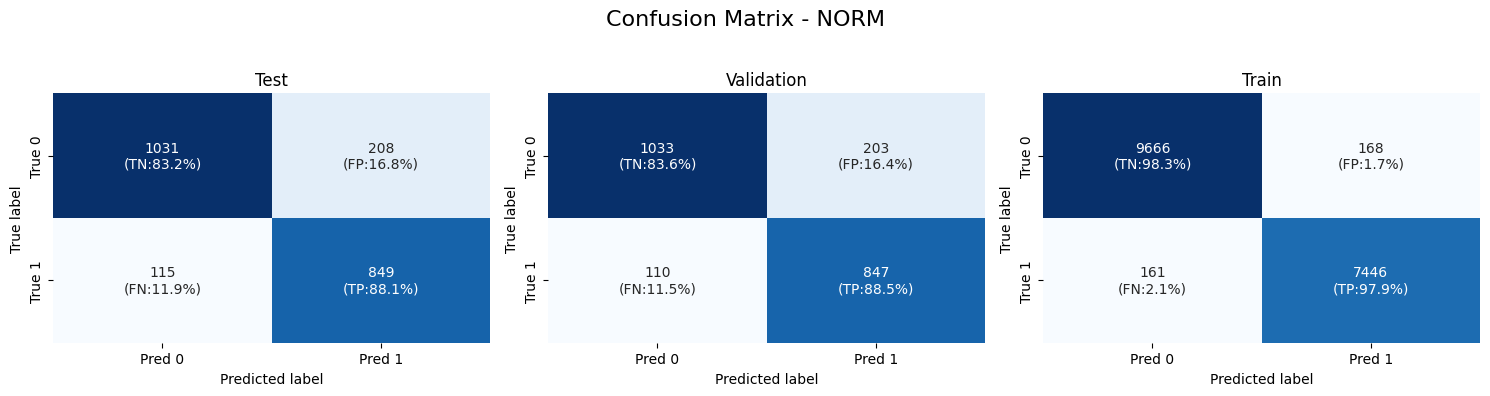

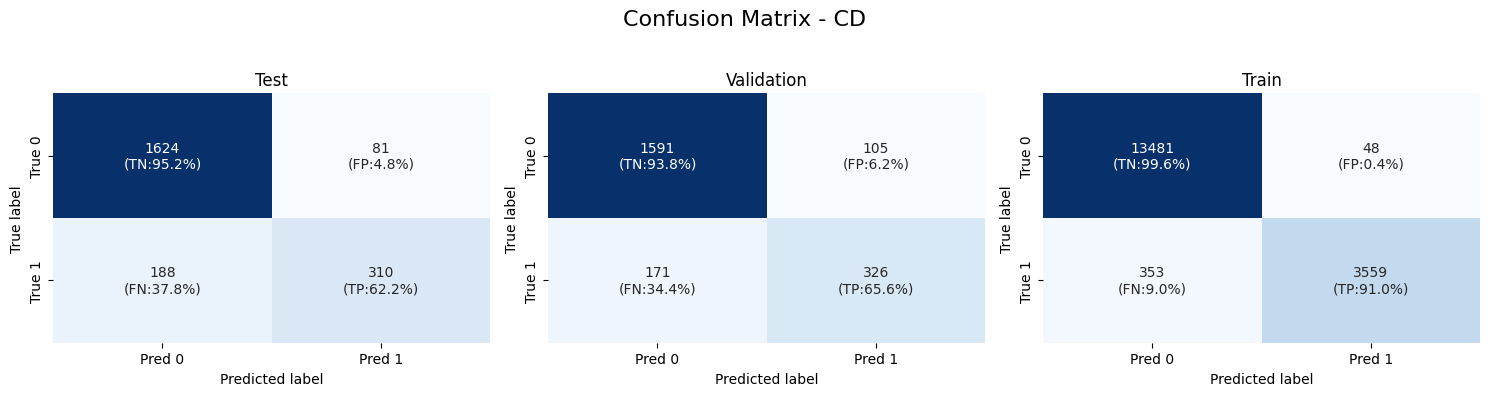

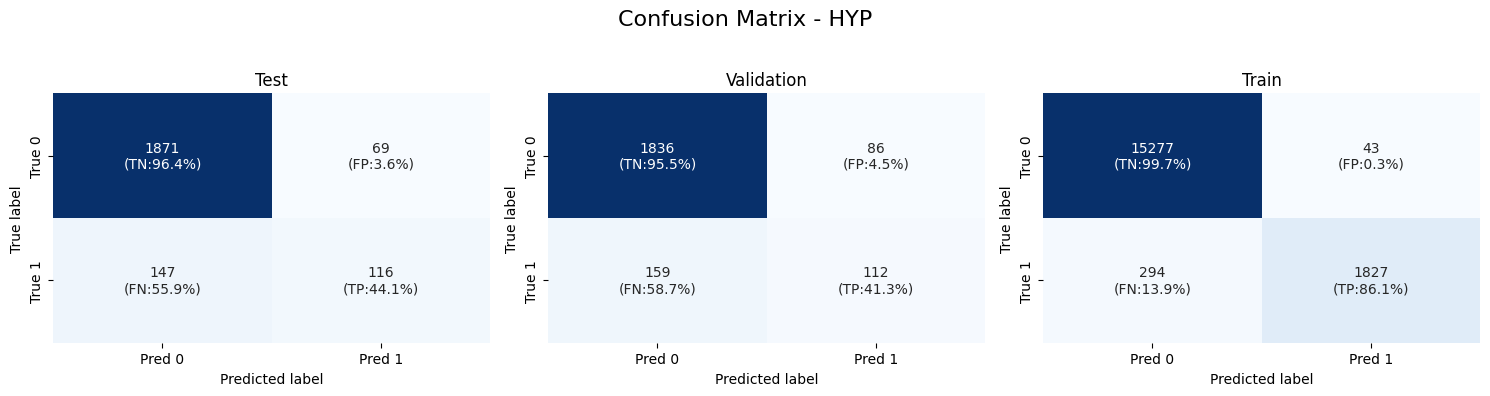

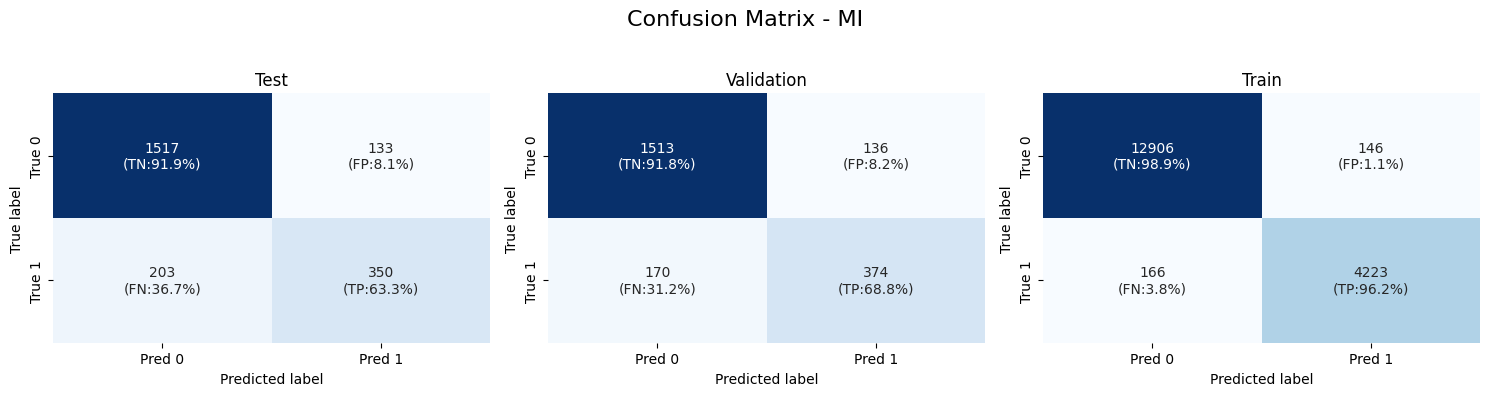

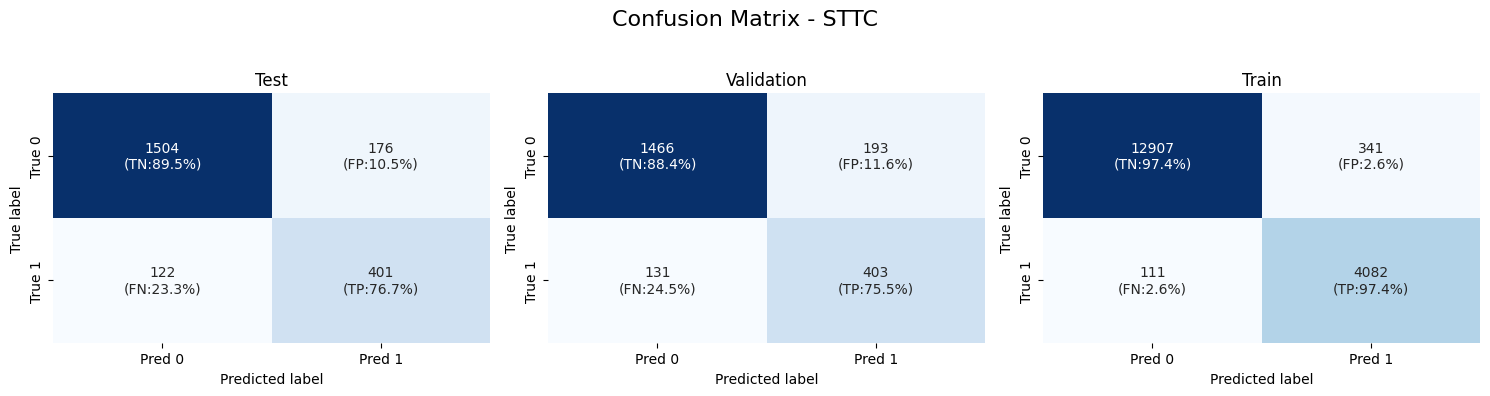

In [13]:
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(label_map.keys()),
    set_names=set_names
)